In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [ ]:
df1 = pd.read_excel('Phuket_landslide_normalized_finaldata1.xlsx', sheet_name='Sheet1')

In [ ]:
df1.columns[14]

'DMR_Geology'

In [ ]:
# Function to load data
def load_data(columns=[3, 4, 5]):
    df = df1.copy()
    df = df.dropna()
    df = df.reset_index(drop=True)
    X = df.iloc[:, columns].to_numpy()
    y = df.iloc[:, -1].to_numpy()
    return {"X": X, "y": y}

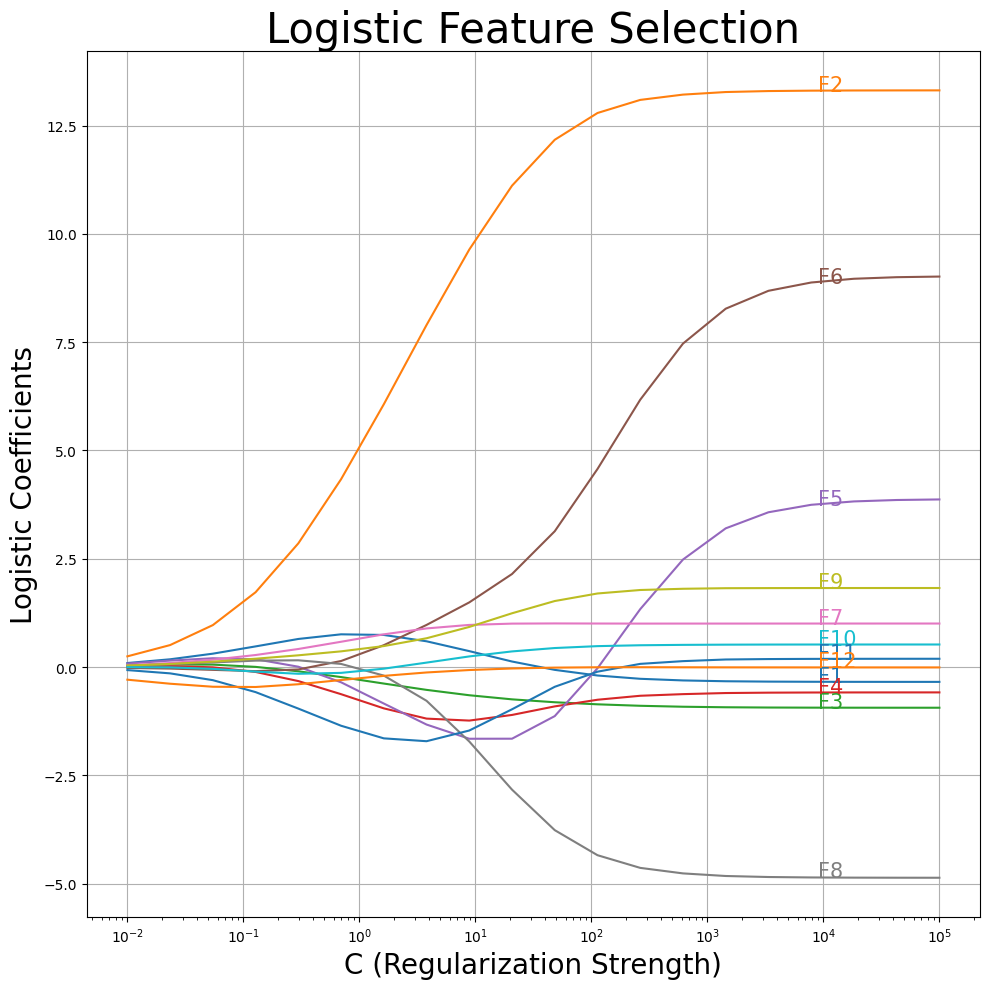

In [ ]:
# Load the dataset
columns = np.arange(3, 15)  # main
data = load_data(columns=columns)
X, y = data["X"], data["y"]

# Define a range of C values (inverse of regularization strength)
C_values = np.logspace(-2, 5, 20)  # Log-spaced values from 0.001 to 1000

coefficients_logistic_l2 = []

# Train models for each C value and store coefficients
for C in C_values:

    # L2-Logistic Regression
    model_logistic_l2 = LogisticRegression(penalty='l2', solver='liblinear', C=C)
    model_logistic_l2.fit(X, y)
    coefficients_logistic_l2.append(model_logistic_l2.coef_[0])

# Convert lists to NumPy arrays
coefficients_logistic_l2 = np.array(coefficients_logistic_l2)

# Create subplots (1x1 layout)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
(ax4) = axs

k = 4 * (20 // 5)  # Annotation index




# Plot L2-Logistic coefficients
for i in range(coefficients_logistic_l2.shape[1]):
    ax4.plot(C_values, coefficients_logistic_l2[:, i], label=f'Feature {i+1}', linestyle='-')
    ax4.annotate(f'F{i+1}', xy=(C_values[k], coefficients_logistic_l2[k, i]), xytext=(5, 0),
                 textcoords='offset points', fontsize=15, color=ax4.lines[-1].get_color())
ax4.set_xscale('log')
ax4.set_xlabel('C (Regularization Strength)',fontsize=20)
ax4.set_ylabel('Logistic Coefficients',fontsize=20)
ax4.set_title('Logistic Feature Selection',fontsize=30)
ax4.grid(True)

fig.tight_layout()
plt.savefig('FeatureSelectLogis.png', dpi=300)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

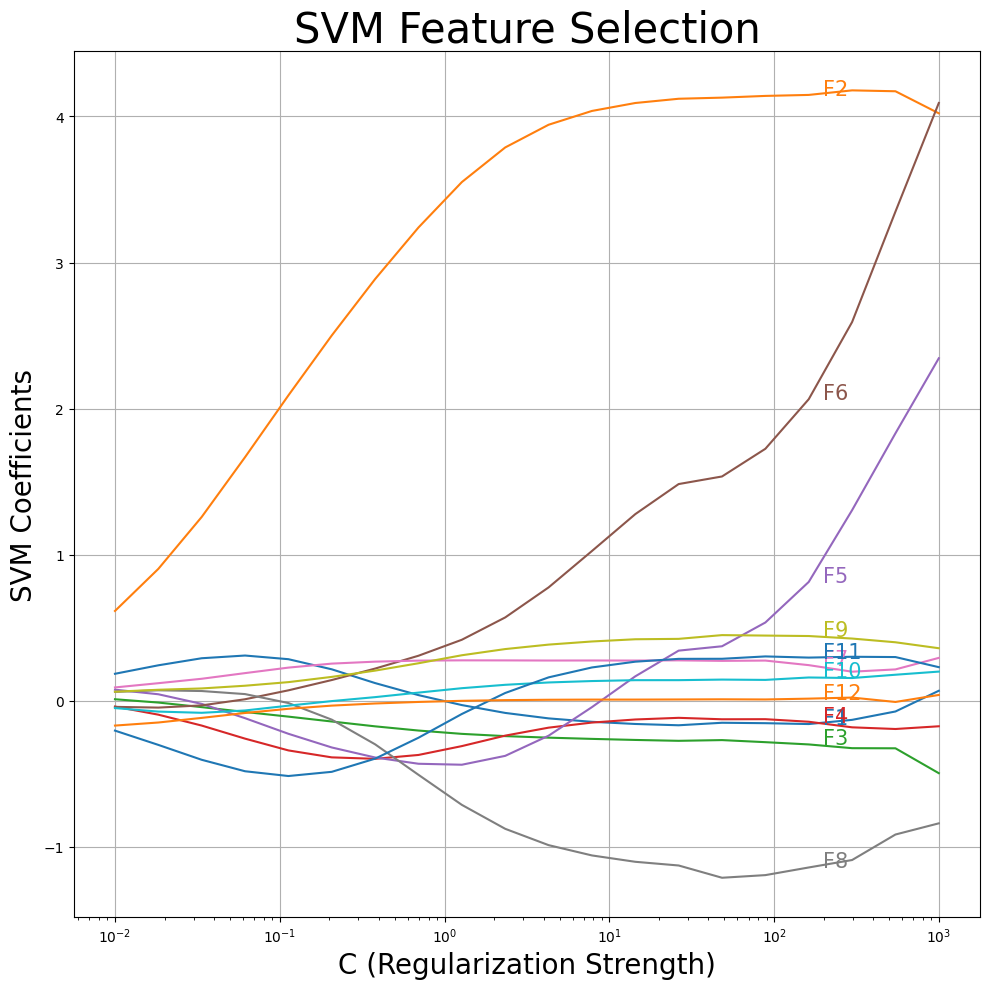

In [ ]:
# Load the dataset
columns = np.arange(3, 15)  # main
data = load_data(columns=columns)
X, y = data["X"], data["y"]
 # Log-spaced values from 0.001 to 1000
C_values1 = np.logspace(-2, 3, 20)
coefficients_svm_l2 = []

# Train models for each C value and store coefficients
for C in C_values1:

    # L2-SVM
    model_svm_l2 = LinearSVC(penalty='l2', dual=True, C=C, max_iter=10000)
    model_svm_l2.fit(X, y)
    coefficients_svm_l2.append(model_svm_l2.coef_[0])

# Convert lists to NumPy arrays
coefficients_svm_l2 = np.array(coefficients_svm_l2)

# Create subplots (1x1 layout)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
(ax3) = axs

k = 4 * (20 // 5)  # Annotation index


# Plot L2-SVM coefficients
for i in range(coefficients_svm_l2.shape[1]):
    ax3.plot(C_values1, coefficients_svm_l2[:, i], label=f'Feature {i+1}', linestyle='-')
    ax3.annotate(f'F{i+1}', xy=(C_values1[k], coefficients_svm_l2[k, i]), xytext=(10, 0),
                 textcoords='offset points', fontsize=15, color=ax3.lines[-1].get_color())
ax3.set_xscale('log')
ax3.set_xlabel('C (Regularization Strength)', fontsize=20)
ax3.set_ylabel('SVM Coefficients',fontsize=20)
ax3.set_title('SVM Feature Selection',fontsize=30)
ax3.grid(True)


fig.tight_layout()
plt.savefig('FeatureSelectSVM.png', dpi=300)
plt.show()
